BuyBox-winner-search logic: A/B test split
--------------------------------------------
Splits an exported SKU pricing file into two comparable groups for a
controlled experiment:
  - Group A: BuyBox-winner-search logic stays ON  (test)
  - Group B: BuyBox-winner-search logic turned OFF (control)

Method: stratified random split (50/50), same idea as a stratified
train/test split in ML. Strata = storefront (amazon_account) x price
quintile, since the export has no explicit volume/margin column and
price tier is the closest available proxy.

Usage:
    python ab_split_buybox_logic.py

Edit SRC_PATH / OUT_PATH / SEED below as needed.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# config
SRC_PATH = '/content/drive/MyDrive/ML1/data/workdata/2026-06-16_amazon_pricing.xlsx'
SRC_SHEET = '2026-06-16_amazon_pricing'

SEED = 42
N_PRICE_TIERS = 5

KEEP_COLS = [
    "amazon_account", "sku", "variant_id", "asin", "InventoryID",
    "dynamic_pricing_status", "feed_regular_sale_price", "MAP",
    "minimum_acceptable_price", "is_buybox_winner", "is_prime",
    "amazon_offer_status", "amazon_offer_price", "price_tier",
    "experiment_group",
]

In [9]:
# data load
df = pd.read_excel(SRC_PATH, sheet_name=SRC_SHEET)
df.head() #looking on top 5 rows of the dataset

,amazon_account,variant_id,sku,is_buybox_winner,InventoryID,asin,dynamic_pricing_status,dynamic_pricing_status_updated_at,dynamic_sale_price,dynamic_sale_price_updated_at,...,MAP,is_prime,minimum_acceptable_price,amazon_offer_status,amazon_offer_price,amazon_offer_shipping_cost,amazon_offer_is_buybox_winner,amazon_offer_updated_at,summary,summary_snoozed_classification
0,amazon_opticsplanet,977967,K7-CB-SCAMAR-PHAA20585,1,988549.0,B004JLUDBW,snoozed,2026-06-16 05:02:31,NaN,2026-06-16 05:02:31,...,NaN,False,41.12,Active,37.99,6.99,1.0,2026-03-10 11:19:21,2026-06-16 05:02:31: [snoozed] Support only sh...,"Support only shipping templates ""ShippingTempl..."
1,amazon_opticsplanet,154021,VX-BI-R385-R385,0,178453.0,NaN,declined,2026-03-22 02:54:06,NaN,2026-03-22 02:54:06,...,99.00,False,92.19,NaN,99.00,0.00,0.0,2026-03-10 06:10:43,2026-03-22 02:54:06: [declined] Item is not on...,NaN
2,amazon_opticsplanet,1459520,8C-CB-20091,1,1474591.0,B071J8HB4T,completed,2026-06-16 09:38:07,81.06,2026-06-13 16:37:16,...,60.49,False,50.40,Active,81.06,0.00,1.0,2026-06-16 09:36:56,2026-06-16 09:38:07: [completed] COMPLETED che...,NaN
3,amazon_opticsplanet,5381687,9V-TG1-DAOHCS-RR2000,0,3586563.0,B0B7SP4HMK,initialized,2026-06-14 18:01:18,NaN,2026-06-14 18:01:18,...,NaN,False,121.75,Active,NaN,NaN,NaN,NaT,2026-06-14 18:01:18: [initialized] Waiting for...,NaN
4,amazon_opticsplanet,5849063,K7-CB-QQ43-SCRTY20615P,0,4049199.0,NaN,declined,2026-03-24 02:54:07,NaN,2026-03-24 02:54:07,...,NaN,False,50.87,NaN,NaN,NaN,NaN,NaT,2026-03-24 02:54:07: [declined] Item is not on...,NaN


##Exploratory data analysis (EDA)

In [10]:
print(df.shape) #size of the dataset
df.info() #columns info

(64599, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64599 entries, 0 to 64598
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   amazon_account                     64599 non-null  object        
 1   variant_id                         64599 non-null  int64         
 2   sku                                64597 non-null  object        
 3   is_buybox_winner                   64599 non-null  int64         
 4   InventoryID                        64579 non-null  float64       
 5   asin                               36391 non-null  object        
 6   dynamic_pricing_status             64599 non-null  object        
 7   dynamic_pricing_status_updated_at  64599 non-null  datetime64[ns]
 8   dynamic_sale_price                 1892 non-null   float64       
 9   dynamic_sale_price_updated_at      64599 non-null  datetime64[ns]
 10  feed_regular_sale_pric

In [11]:
df.isna().sum().sort_values(ascending=False)

,0
dynamic_sale_price,62707
amazon_offer_shipping_cost,44852
amazon_offer_price,44852
amazon_offer_is_buybox_winner,44852
amazon_offer_updated_at,44004
amazon_offer_status,28208
asin,28208
MAP,27878
summary_snoozed_classification,25468
minimum_acceptable_price,27


In [12]:
# Перевірка: чи (amazon_account, variant_id, sku) - унікальний ідентифікатор
key_cols = ['amazon_account', 'variant_id', 'sku']

n_total = len(df)
n_unique = df[key_cols].drop_duplicates().shape[0]
n_dup_rows = df.duplicated(key_cols).sum()

print(f"Всього рядків: {n_total}")
print(f"Унікальних комбінацій {key_cols}: {n_unique}")
print(f"Дубльованих рядків за цим ключем: {n_dup_rows}")
print(f"Ключ унікальний: {n_dup_rows == 0}")

Всього рядків: 64599
Унікальних комбінацій ['amazon_account', 'variant_id', 'sku']: 64556
Дубльованих рядків за цим ключем: 43
Ключ унікальний: False


In [16]:
# show duplicates
if n_dup_rows > 0:
    dup_mask = df.duplicated(key_cols, keep=False)
    display(df[dup_mask].sort_values(key_cols))


,amazon_account,variant_id,sku,is_buybox_winner,InventoryID,asin,dynamic_pricing_status,dynamic_pricing_status_updated_at,dynamic_sale_price,dynamic_sale_price_updated_at,...,MAP,is_prime,minimum_acceptable_price,amazon_offer_status,amazon_offer_price,amazon_offer_shipping_cost,amazon_offer_is_buybox_winner,amazon_offer_updated_at,summary,summary_snoozed_classification
21212,amazon_opticsplanet,3185,AL-SS-788-EE,0,1905.0,B0001IPKRE,snoozed,2026-06-16 04:13:39,NaN,2026-06-16 04:13:39,...,349.99,True,384.99,Active,384.99,0.00,0.0,2026-06-16 05:17:04,2026-06-16 04:13:39: [snoozed] MinimumAcceptab...,MinimumAcceptablePrice does not lead to win Bu...
21213,amazon_opticsplanet,3185,AL-SS-788-EE,0,1905.0,B0001IPKRE,snoozed,2026-06-16 04:13:39,NaN,2026-06-16 04:13:39,...,349.99,True,384.99,Inactive,384.99,0.00,0.0,2026-06-16 05:17:04,2026-06-16 04:13:39: [snoozed] MinimumAcceptab...,MinimumAcceptablePrice does not lead to win Bu...
20815,amazon_opticsplanet,17134,BR-SAP-SDM-410332,0,7389.0,B0041US3SQ,pricing,2026-06-14 17:06:42,61.43,2026-06-14 17:06:42,...,NaN,False,61.43,Inactive,63.19,0.00,0.0,2026-06-14 17:05:51,2026-06-14 17:06:42: [pricing] Testing Minimum...,NaN
20816,amazon_opticsplanet,17134,BR-SAP-SDM-410332,0,7389.0,B0041US3SQ,pricing,2026-06-14 17:06:42,61.43,2026-06-14 17:06:42,...,NaN,False,61.43,Active,63.19,0.00,0.0,2026-06-14 17:05:51,2026-06-14 17:06:42: [pricing] Testing Minimum...,NaN
19245,amazon_opticsplanet,17147,BR-SCM-ARTM-410341,1,158159.0,B0028JNRW4,snoozed,2026-06-15 13:03:23,NaN,2026-06-15 13:03:23,...,NaN,False,56.73,Inactive,63.27,9.99,1.0,2026-06-05 03:09:34,2026-06-15 13:03:23: [snoozed] Support only sh...,"Support only shipping templates ""ShippingTempl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20938,amazon_opticsplanet,5704435,1SC-SCM-WLRP-LT845,0,3905187.0,B01APWH4UQ,snoozed,2026-06-15 12:02:17,NaN,2026-06-15 12:02:17,...,419.99,False,427.44,Inactive,427.41,0.00,0.0,2026-05-09 08:06:16,2026-06-15 12:02:17: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
22202,amazon_opticsplanet,5704475,1SC-SCM-CANSCM-LT204-30,0,3905227.0,B0CZPCZ3SC,snoozed,2026-06-15 11:01:23,NaN,2026-06-15 11:01:23,...,274.99,False,289.07,Inactive,274.99,0.00,0.0,2026-05-09 16:05:49,2026-06-15 11:01:23: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
22203,amazon_opticsplanet,5704475,1SC-SCM-CANSCM-LT204-30,0,3905227.0,B0CZPCZ3SC,snoozed,2026-06-15 11:01:23,NaN,2026-06-15 11:01:23,...,274.99,False,289.07,Inactive,274.99,0.00,0.0,2026-05-09 16:05:49,2026-06-15 11:01:23: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
22289,amazon_opticsplanet,5730087,OS-RFB-RANGFB-BIN-OSP-10X42LRF,0,3930287.0,B0CTR1PC63,snoozed,2026-06-16 05:03:34,NaN,2026-06-16 05:03:34,...,449.99,False,322.83,Active,NaN,NaN,NaN,NaT,"2026-06-16 05:03:34: [snoozed] SKU is FBA, wak...",SKU is FBA


In [17]:
# check duplicates by key_cols

# Беремо тільки рядки, що входять у дубльовані групи (обидві копії, не тільки "зайві")
dup_mask = df.duplicated(key_cols, keep=False)
dup_rows = df[dup_mask].sort_values(key_cols)

# Для кожної групи дублів рахуємо, в яких колонках значення різняться
def check_diffs(group):
    diffs = group.nunique()
    return diffs[diffs > 1].index.tolist()

diff_report = dup_rows.groupby(key_cols).apply(check_diffs)
print(diff_report)

amazon_account       variant_id  sku                           
amazon_opticsplanet  3185        AL-SS-788-EE                      [amazon_offer_status]
                     17134       BR-SAP-SDM-410332                 [amazon_offer_status]
                     17147       BR-SCM-ARTM-410341                [amazon_offer_status]
                     17148       BR-SCM-ARTM-410343                [amazon_offer_status]
                     47067       DZ-SCM-MRLN-12042                 [amazon_offer_status]
                     47217       DZ-SCM-TIKKA-T330-30550           [amazon_offer_status]
                     83109       NF-RR-ULTRALITE-A107              [amazon_offer_status]
                     517633      KK-SAP-FVCP-49414                 [amazon_offer_status]
                     589499      DZ-SCM-SVGEDGE-52200              [amazon_offer_status]
                     910231      NF-SCM-MGMNT-A162                                    []
                     1119524     TJ-AP-GL13-C-

/tmp/ipykernel_1450/3031936853.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diff_report = dup_rows.groupby(key_cols).apply(check_diffs)


In [18]:
# Порахуємо, які колонки найчастіше відрізняються серед усіх дублів
from collections import Counter

all_diff_cols = [col for cols in diff_report for col in cols]
print(Counter(all_diff_cols))

Counter({'amazon_offer_status': 32, 'asin': 1})


In [19]:
# groups details, де відрізняється amazon_offer_status
status_diff_keys = pd.DataFrame(
    [k for k, cols in diff_report.items() if 'amazon_offer_status' in cols],
    columns=key_cols
)

detail = df.merge(status_diff_keys, on=key_cols)
display(detail.sort_values(key_cols)[key_cols + ['amazon_offer_status', 'amazon_offer_updated_at']])

,amazon_account,variant_id,sku,amazon_offer_status,amazon_offer_updated_at
39,amazon_opticsplanet,3185,AL-SS-788-EE,Active,2026-06-16 05:17:04
40,amazon_opticsplanet,3185,AL-SS-788-EE,Inactive,2026-06-16 05:17:04
37,amazon_opticsplanet,17134,BR-SAP-SDM-410332,Inactive,2026-06-14 17:05:51
38,amazon_opticsplanet,17134,BR-SAP-SDM-410332,Active,2026-06-14 17:05:51
14,amazon_opticsplanet,17147,BR-SCM-ARTM-410341,Inactive,2026-06-05 03:09:34
...,...,...,...,...,...
50,amazon_opticsplanet,5456234,KK-SAP-EGWDEC48-49547,Active,2026-03-10 11:30:16
47,amazon_opticsplanet,5456243,KK-SAP-EGWDEC43-49287,Inactive,2026-03-10 11:30:16
48,amazon_opticsplanet,5456243,KK-SAP-EGWDEC43-49287,Active,2026-03-10 11:30:16
53,amazon_opticsplanet,5456254,KK-SAP-EGWDEC47-49544,Active,2026-03-27 04:41:13


In [20]:
# Завантажуємо СТАРТОВИЙ файл окремо, не чіпаючи поточний df
df_raw = pd.read_excel(SRC_PATH, sheet_name=SRC_SHEET)

# Дістаємо ключі дубльованих груп (з diff_report або напряму)
dup_keys = diff_report.index.to_frame(index=False)

# Мерджимо з ОРИГІНАЛЬНИМ df_raw - там усі рядки на місці, нічого не відфільтровано
full_dup_rows = df_raw.merge(dup_keys, on=key_cols).sort_values(key_cols)
display(full_dup_rows)

,amazon_account,variant_id,sku,is_buybox_winner,InventoryID,asin,dynamic_pricing_status,dynamic_pricing_status_updated_at,dynamic_sale_price,dynamic_sale_price_updated_at,...,MAP,is_prime,minimum_acceptable_price,amazon_offer_status,amazon_offer_price,amazon_offer_shipping_cost,amazon_offer_is_buybox_winner,amazon_offer_updated_at,summary,summary_snoozed_classification
49,amazon_opticsplanet,3185,AL-SS-788-EE,0,1905.0,B0001IPKRE,snoozed,2026-06-16 04:13:39,NaN,2026-06-16 04:13:39,...,349.99,True,384.99,Active,384.99,0.00,0.0,2026-06-16 05:17:04,2026-06-16 04:13:39: [snoozed] MinimumAcceptab...,MinimumAcceptablePrice does not lead to win Bu...
50,amazon_opticsplanet,3185,AL-SS-788-EE,0,1905.0,B0001IPKRE,snoozed,2026-06-16 04:13:39,NaN,2026-06-16 04:13:39,...,349.99,True,384.99,Inactive,384.99,0.00,0.0,2026-06-16 05:17:04,2026-06-16 04:13:39: [snoozed] MinimumAcceptab...,MinimumAcceptablePrice does not lead to win Bu...
45,amazon_opticsplanet,17134,BR-SAP-SDM-410332,0,7389.0,B0041US3SQ,pricing,2026-06-14 17:06:42,61.43,2026-06-14 17:06:42,...,NaN,False,61.43,Inactive,63.19,0.00,0.0,2026-06-14 17:05:51,2026-06-14 17:06:42: [pricing] Testing Minimum...,NaN
46,amazon_opticsplanet,17134,BR-SAP-SDM-410332,0,7389.0,B0041US3SQ,pricing,2026-06-14 17:06:42,61.43,2026-06-14 17:06:42,...,NaN,False,61.43,Active,63.19,0.00,0.0,2026-06-14 17:05:51,2026-06-14 17:06:42: [pricing] Testing Minimum...,NaN
16,amazon_opticsplanet,17147,BR-SCM-ARTM-410341,1,158159.0,B0028JNRW4,snoozed,2026-06-15 13:03:23,NaN,2026-06-15 13:03:23,...,NaN,False,56.73,Inactive,63.27,9.99,1.0,2026-06-05 03:09:34,2026-06-15 13:03:23: [snoozed] Support only sh...,"Support only shipping templates ""ShippingTempl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,amazon_opticsplanet,5704435,1SC-SCM-WLRP-LT845,0,3905187.0,B01APWH4UQ,snoozed,2026-06-15 12:02:17,NaN,2026-06-15 12:02:17,...,419.99,False,427.44,Inactive,427.41,0.00,0.0,2026-05-09 08:06:16,2026-06-15 12:02:17: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
51,amazon_opticsplanet,5704475,1SC-SCM-CANSCM-LT204-30,0,3905227.0,B0CZPCZ3SC,snoozed,2026-06-15 11:01:23,NaN,2026-06-15 11:01:23,...,274.99,False,289.07,Inactive,274.99,0.00,0.0,2026-05-09 16:05:49,2026-06-15 11:01:23: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
52,amazon_opticsplanet,5704475,1SC-SCM-CANSCM-LT204-30,0,3905227.0,B0CZPCZ3SC,snoozed,2026-06-15 11:01:23,NaN,2026-06-15 11:01:23,...,274.99,False,289.07,Inactive,274.99,0.00,0.0,2026-05-09 16:05:49,2026-06-15 11:01:23: [snoozed] Item is not sel...,Item is not sellable on Amazon. QOH on Amazon ...
55,amazon_opticsplanet,5730087,OS-RFB-RANGFB-BIN-OSP-10X42LRF,0,3930287.0,B0CTR1PC63,snoozed,2026-06-16 05:03:34,NaN,2026-06-16 05:03:34,...,449.99,False,322.83,Active,NaN,NaN,NaN,NaT,"2026-06-16 05:03:34: [snoozed] SKU is FBA, wak...",SKU is FBA


In [23]:
# check for duplicated values within all data available in excel

dup_mask_raw = df_raw.duplicated(key_cols, keep=False)
dup_rows_raw = df_raw[dup_mask_raw].sort_values(key_cols)

def check_diffs(group):
    diffs = group.nunique()
    return diffs[diffs > 1].index.tolist()

diff_report2 = dup_rows_raw.groupby(key_cols).apply(check_diffs, include_groups=False)
print(diff_report2)

amazon_account       variant_id  sku                           
amazon_opticsplanet  3185        AL-SS-788-EE                      [amazon_offer_status]
                     17134       BR-SAP-SDM-410332                 [amazon_offer_status]
                     17147       BR-SCM-ARTM-410341                [amazon_offer_status]
                     17148       BR-SCM-ARTM-410343                [amazon_offer_status]
                     47067       DZ-SCM-MRLN-12042                 [amazon_offer_status]
                     47217       DZ-SCM-TIKKA-T330-30550           [amazon_offer_status]
                     83109       NF-RR-ULTRALITE-A107              [amazon_offer_status]
                     517633      KK-SAP-FVCP-49414                 [amazon_offer_status]
                     589499      DZ-SCM-SVGEDGE-52200              [amazon_offer_status]
                     910231      NF-SCM-MGMNT-A162                                    []
                     1119524     TJ-AP-GL13-C-

In original file there is no criteria for detecting order for duplicated values.

In [24]:
key_cols = ['amazon_account', 'variant_id', 'sku']

# 1. Позначаємо рядки, що входили в дубльовану групу (ДО очищення)
df_raw['had_duplicates'] = df_raw.duplicated(key_cols, keep=False)

# 2. Прибираємо дублікати, залишаючи ОСТАННІЙ рядок у кожній групі
df_clean = df_raw.drop_duplicates(subset=key_cols, keep='last').reset_index(drop=True)

print("До очищення:", df_raw.shape)
print("Після очищення:", df_clean.shape)
print("Рядків з прапорцем had_duplicates=True:", df_clean['had_duplicates'].sum())

До очищення: (64599, 22)
Після очищення: (64556, 22)
Рядків з прапорцем had_duplicates=True: 42


прибрано 43 рядки, не 42 — і це коректно, а не помилка. Причина: 41 група мала по 2 рядки (з кожної видалили 1 → 41 видалено), а 1 група (variant_id=17147) мала 3 рядки (з неї видалили 2 → лишився 1). Разом: 41 + 2 = 43 видалених рядки.

In [28]:
# step 1: split on cleaned data
np.random.seed(SEED) # fixation of randomality for future getting same result

n_total = len(df_clean)
df_split = df_clean.copy()  # окрема копія, щоб не псувати df_clean новими колонками


def price_tier(group):
    try:
        return pd.qcut(group, N_PRICE_TIERS, labels=False, duplicates="drop")
    except ValueError:
        return pd.qcut(group, 3, labels=False, duplicates="drop") #pd.qcut ділить числа на N груп однакового розміру за квантилями (не за рівними інтервалами ціни, а так, щоб у кожній групі було приблизно однакова кількість SKU)
    #  try/except тут — захист: якщо в даних забагато однакових цін (наприклад, купа товарів по $9.99),
    #  qcut не зможе поділити рівно на 5 унікальних меж і викине ValueError.
    # Тоді функція підстраховується і ділить на 3 групи замість 5 (duplicates="drop" каже "просто злий однакові межі в одну").


df_split["price_tier"] = df_split.groupby("amazon_account")["feed_regular_sale_price"].transform(price_tier) #each amazon account separately

df_split["stratum"] = df_split["amazon_account"] + "_tier" + df_split["price_tier"].astype(str)

"""
Просто текстове склеювання: "amazon_opticsplanet_tier2", "amazon_campsaver_tier0" тощо.
Це і є фінальна група, всередині якої робитимемо випадковий поділ 50/50 — так гарантуємо,
що в обох групах A і B буде однаковий мікс акаунтів і цінових категорій, а не випадковий перекіс.
"""

def assign_group(g):
    idx = g.sample(frac=1, random_state=SEED).index #takes all table in random order; frac=1 - all table
    half = len(idx) // 2
    labels = pd.Series("B - Logic OFF (control)", index=g.index)
    labels.loc[idx[: half + (len(idx) % 2)]] = "A - Logic ON (test)" #rewrite to A half
    return labels


df_split["experiment_group"] = df_split.groupby("stratum", group_keys=False).apply(assign_group, include_groups=False)

print("Rows in split population:", len(df_split))



Rows in split population: 64556


In [29]:
# step 2: sanity checks
dup_listing = df_split.duplicated(["amazon_account", "sku"]).sum()
dup_variant = df_split.duplicated(["amazon_account", "variant_id"]).sum()

df_split["_listing_key"] = df_split["amazon_account"] + "_" + df_split["variant_id"].astype(str)
overlap = set(df_split.loc[df_split.experiment_group.str.startswith("A"), "_listing_key"]) & \
          set(df_split.loc[df_split.experiment_group.str.startswith("B"), "_listing_key"])

groupA_price = df_split.loc[df_split.experiment_group.str.startswith("A"), "feed_regular_sale_price"]
groupB_price = df_split.loc[df_split.experiment_group.str.startswith("B"), "feed_regular_sale_price"]
t_stat, p_val = stats.ttest_ind(groupA_price, groupB_price, equal_var=False)
ks_stat, ks_p = stats.ks_2samp(groupA_price, groupB_price)

print(f"Split population: {len(df_split)}")
print(df_split["experiment_group"].value_counts(), "\n")
print("By account:\n", pd.crosstab(df_split["amazon_account"], df_split["experiment_group"]), "\n")
print("Price stats by group:\n",
      df_split.groupby("experiment_group")["feed_regular_sale_price"].agg(["count", "mean", "median", "std"]), "\n")
print(f"Welch t-test price A vs B: t={t_stat:.3f}, p={p_val:.4f}")
print(f"KS test price A vs B: stat={ks_stat:.4f}, p={ks_p:.4f}")
print(f"Duplicate (account, sku) rows remaining: {dup_listing}")
print(f"Duplicate (account, variant_id) rows remaining: {dup_variant}")
print(f"Listings landing in BOTH groups: {len(overlap)}")

Split population: 64556
experiment_group
A - Logic ON (test)        32281
B - Logic OFF (control)    32275
Name: count, dtype: int64 

By account:
 experiment_group     A - Logic ON (test)  B - Logic OFF (control)
amazon_account                                                   
amazon_campsaver                   14100                    14097
amazon_opticsplanet                18181                    18178 

Price stats by group:
                          count        mean  median         std
experiment_group                                              
A - Logic ON (test)      32281  151.477963   67.99  344.304864
B - Logic OFF (control)  32275  153.779463   67.49  359.466049 

Welch t-test price A vs B: t=-0.831, p=0.4061
KS test price A vs B: stat=0.0053, p=0.7487
Duplicate (account, sku) rows remaining: 4
Duplicate (account, variant_id) rows remaining: 0
Listings landing in BOTH groups: 0


After deduplication (removing 43 duplicate rows), the split was rebuilt on df_split (64,556 rows).

Groups A/B are balanced by size (32,281 vs 32,275), account, and price (Welch p=0.41, KS p=0.75 — no statistically significant difference).

The cross-group duplicate leakage has been fully resolved (0 overlaps, down from 18). 4 cases of (account, sku) duplication remain - three of them legitimate (one SKU with multiple variant_ids), requiring no action.

In [30]:
# step 3: build workbook for separate groups A and B
dfA = df_split.loc[df_split.experiment_group.str.startswith("A"), KEEP_COLS].reset_index(drop=True)
dfB = df_split.loc[df_split.experiment_group.str.startswith("B"), KEEP_COLS].reset_index(drop=True)
nA, nB = len(dfA), len(dfB)

In [31]:
print(nA, nB)

32281 32275


In [32]:
OUT_PATH = "AB_test_split_buybox_logic.xlsx"

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    dfA.to_excel(writer, sheet_name="Group_A_Logic_ON", index=False)
    dfB.to_excel(writer, sheet_name="Group_B_Logic_OFF", index=False)

wb = load_workbook(OUT_PATH)

HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF")
HEADER_FILL = PatternFill("solid", start_color="4472C4")
BODY_FONT = Font(name="Arial", size=10)

for sheet_name, sheet_df in [("Group_A_Logic_ON", dfA), ("Group_B_Logic_OFF", dfB)]:
    ws = wb[sheet_name]
    for cell in ws[1]:
        cell.font = HEADER_FONT
        cell.fill = HEADER_FILL
        cell.alignment = Alignment(horizontal="center")
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.font = BODY_FONT
    for i, col in enumerate(sheet_df.columns, 1):
        ws.column_dimensions[get_column_letter(i)].width = max(14, len(col) + 2)
    ws.freeze_panes = "A2"

In [34]:
# creation of Summary page
summary = wb.create_sheet("Balance_Summary", 0)

rows = [
    ("A/B Test Split — BuyBox-Winner-Search Logic", None),
    ("", None),
    ("Methodology", None),
    ("Population", "SKU listings after removing 43 technical duplicate rows (df_clean)"),
    ("Randomization unit", "Each row = one SKU listing (amazon_account + variant_id)"),
    ("Stratification", "Storefront (amazon_account) x price quintile (feed_regular_sale_price); "
                        "no volume/margin field exists in the export, so price tier is used as the closest proxy"),
    ("Split ratio", f"50% / 50% within each stratum, randomized with fixed seed ({SEED}) for reproducibility"),
    ("Group A", "BuyBox-winner-search logic stays ON (test)"),
    ("Group B", "BuyBox-winner-search logic turned OFF (control)"),
    ("", None),
    ("Balance Check", None),
    ("Metric", "Group A (Logic ON)", "Group B (Logic OFF)"),
    ("SKU count", f"=COUNTA(Group_A_Logic_ON!A2:A{nA + 1})", f"=COUNTA(Group_B_Logic_OFF!A2:A{nB + 1})"),
    ("% of total", "=B13/(B13+C13)", "=C13/(B13+C13)"),
    ("amazon_opticsplanet count",
     f'=COUNTIF(Group_A_Logic_ON!A2:A{nA + 1},"amazon_opticsplanet")',
     f'=COUNTIF(Group_B_Logic_OFF!A2:A{nB + 1},"amazon_opticsplanet")'),
    ("amazon_campsaver count",
     f'=COUNTIF(Group_A_Logic_ON!A2:A{nA + 1},"amazon_campsaver")',
     f'=COUNTIF(Group_B_Logic_OFF!A2:A{nB + 1},"amazon_campsaver")'),
    ("Avg price ($)", f"=AVERAGE(Group_A_Logic_ON!G2:G{nA + 1})", f"=AVERAGE(Group_B_Logic_OFF!G2:G{nB + 1})"),
    ("Median price ($)", f"=MEDIAN(Group_A_Logic_ON!G2:G{nA + 1})", f"=MEDIAN(Group_B_Logic_OFF!G2:G{nB + 1})"),
    ("St. dev price ($)", f"=STDEV(Group_A_Logic_ON!G2:G{nA + 1})", f"=STDEV(Group_B_Logic_OFF!G2:G{nB + 1})"),
    ("Current BuyBox-winner rate", f"=AVERAGE(Group_A_Logic_ON!J2:J{nA + 1})", f"=AVERAGE(Group_B_Logic_OFF!J2:J{nB + 1})"),
    ("Prime rate", f"=AVERAGE(Group_A_Logic_ON!K2:K{nA + 1})", f"=AVERAGE(Group_B_Logic_OFF!K2:K{nB + 1})"),
    ("", None),
    ("Statistical check (computed in Python, not live formulas)", None),
    ("Welch t-test on price, A vs B", f"t = {t_stat:.3f}, p = {p_val:.3f}"),
    ("KS test on price distribution, A vs B", f"stat = {ks_stat:.3f}, p = {ks_p:.3f}"),
    ("", None),
    ("Data quality notes", None),
    ("- 43 fully duplicate rows removed before the split (kept 'Active' status when present)", None),
    ("- 4 remaining (account, sku) duplicates: 3 legitimate (one SKU, multiple variant_ids)", None),
    ("- Cross-group listing overlap: 0 (verified)", None),
]

for r in rows:
    summary.append(r if isinstance(r, tuple) else (r,))

summary["A1"].font = Font(name="Arial", bold=True, size=14)
summary["A3"].font = Font(name="Arial", bold=True, size=12)
summary["A11"].font = Font(name="Arial", bold=True, size=12)
summary["A22"].font = Font(name="Arial", bold=True, size=12)
summary["A26"].font = Font(name="Arial", bold=True, size=12)
for cell in summary["A12:C12"][0]:
    cell.font = Font(name="Arial", bold=True)
    cell.fill = PatternFill("solid", start_color="D9E1F2")
for row in summary.iter_rows():
    for cell in row:
        if cell.font.name is None or cell.font.name == "Calibri":
            cell.font = Font(name="Arial", size=10)
summary.column_dimensions["A"].width = 45
summary.column_dimensions["B"].width = 30
summary.column_dimensions["C"].width = 30

In [35]:
wb.save(OUT_PATH)
print("Saved:", OUT_PATH)

Saved: AB_test_split_buybox_logic.xlsx


In [37]:
from google.colab import files
files.download(OUT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

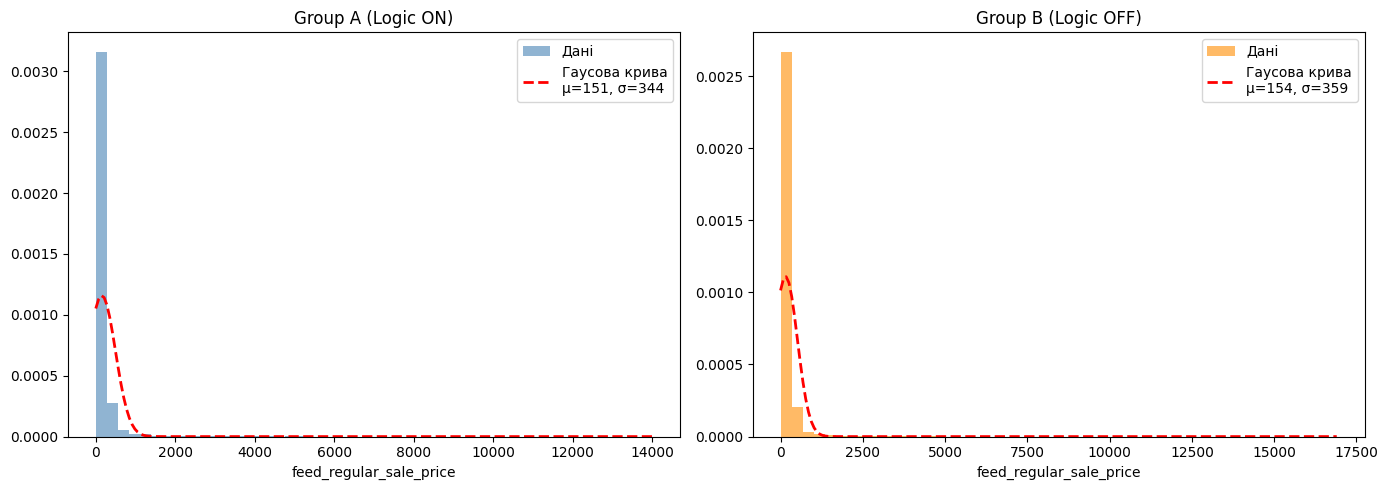

In [38]:
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, price, label, color in zip(
    axes,
    [groupA_price, groupB_price],
    ['Group A (Logic ON)', 'Group B (Logic OFF)'],
    ['steelblue', 'darkorange']
):
    ax.hist(price, bins=50, density=True, alpha=0.6, color=color, label='Дані')

    mu, sigma = norm.fit(price)
    x = np.linspace(price.min(), price.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label=f'Гаусова крива\nμ={mu:.0f}, σ={sigma:.0f}')

    ax.set_title(label)
    ax.set_xlabel('feed_regular_sale_price')
    ax.legend()

plt.tight_layout()
plt.show()

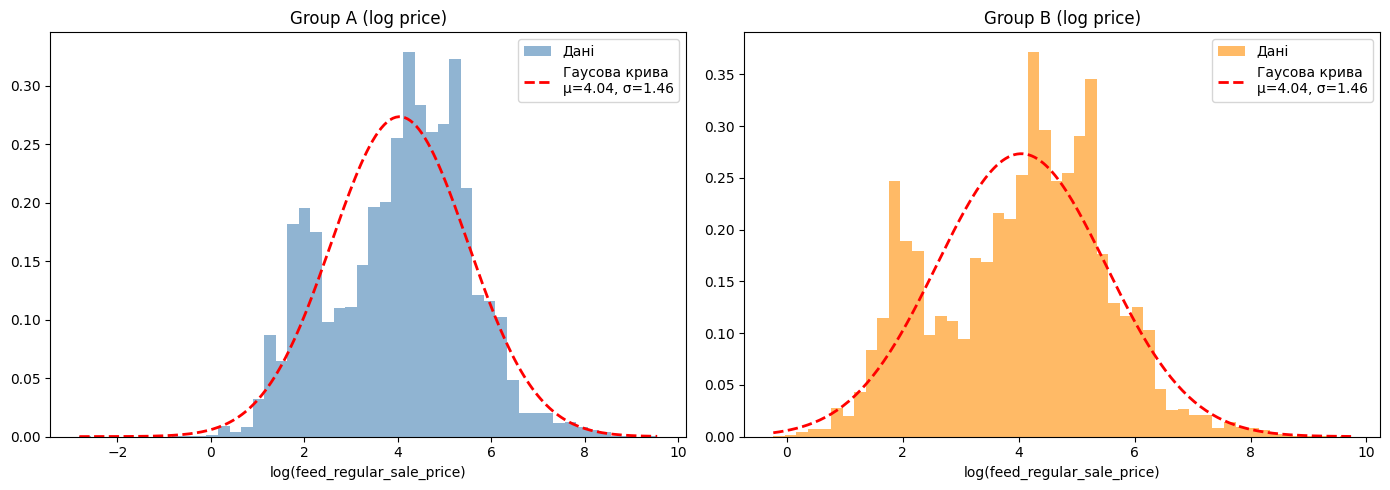

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, price, label, color in zip(
    axes,
    [np.log(groupA_price), np.log(groupB_price)],
    ['Group A (log price)', 'Group B (log price)'],
    ['steelblue', 'darkorange']
):
    ax.hist(price, bins=50, density=True, alpha=0.6, color=color, label='Дані')

    mu, sigma = norm.fit(price)
    x = np.linspace(price.min(), price.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label=f'Гаусова крива\nμ={mu:.2f}, σ={sigma:.2f}')

    ax.set_title(label)
    ax.set_xlabel('log(feed_regular_sale_price)')
    ax.legend()

plt.tight_layout()
plt.show()

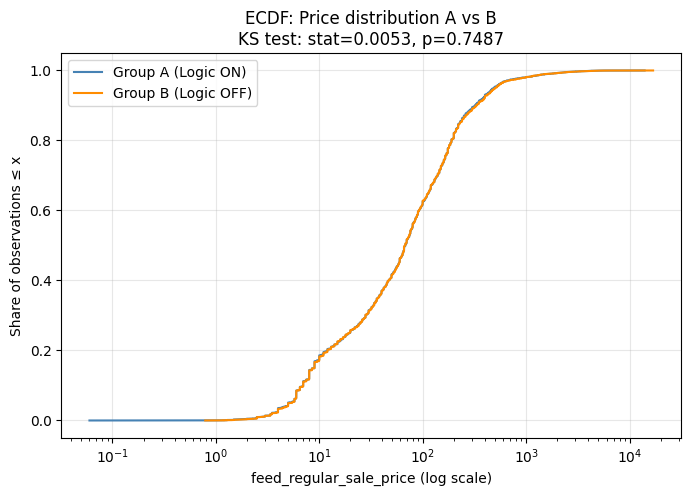

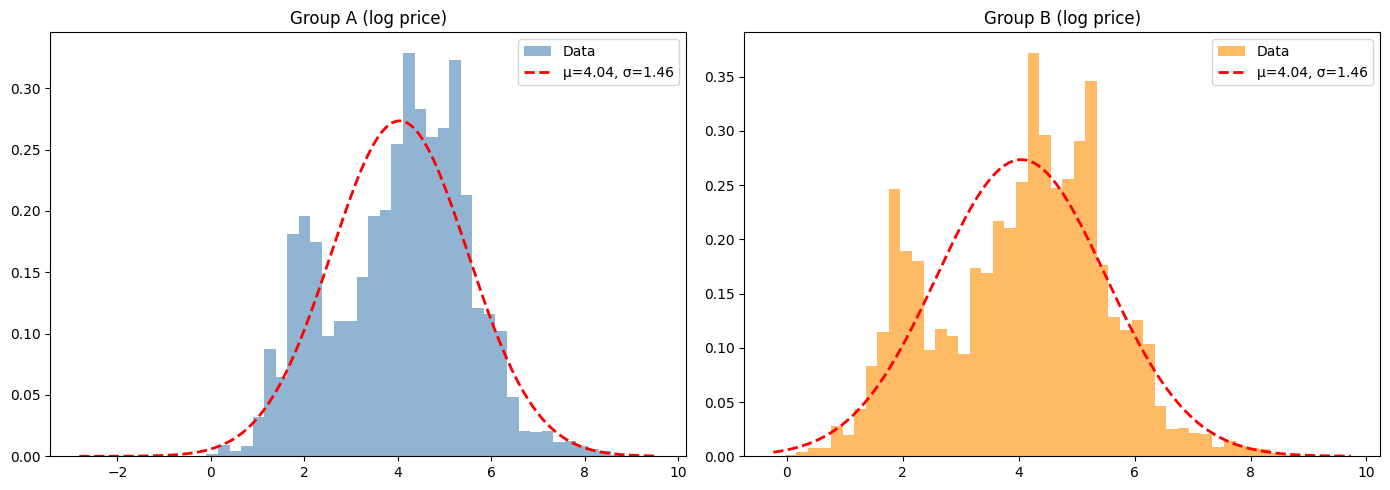

In [42]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Графік 1: ECDF ---
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

xA, yA = ecdf(groupA_price)
xB, yB = ecdf(groupB_price)

plt.figure(figsize=(8, 5))
plt.plot(xA, yA, label='Group A (Logic ON)', color='steelblue')
plt.plot(xB, yB, label='Group B (Logic OFF)', color='darkorange')
plt.xscale('log')
plt.xlabel('feed_regular_sale_price (log scale)')
plt.ylabel('Share of observations ≤ x')
plt.title(f'ECDF: Price distribution A vs B\nKS test: stat={ks_stat:.4f}, p={ks_p:.4f}')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('ecdf_price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Графік 2: лог-гістограма ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, price, label, color in zip(
    axes,
    [np.log(groupA_price), np.log(groupB_price)],
    ['Group A (log price)', 'Group B (log price)'],
    ['steelblue', 'darkorange']
):
    ax.hist(price, bins=50, density=True, alpha=0.6, color=color, label='Data')
    mu, sigma = norm.fit(price)
    x = np.linspace(price.min(), price.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label=f'μ={mu:.2f}, σ={sigma:.2f}')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.savefig('log_price_histograms.png', dpi=150, bbox_inches='tight')
plt.show()